In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

In [7]:
train = pd.read_csv('train_eda.csv')
train.head(2)

,msno,song_id,source_system_tab,source_screen_name,source_type,target,city,bd,gender,registered_via,...,genre_ids,artist_name,composer,lyricist,language,primary_genre,song_length_sec,name,isrc,isrc_year
0,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,13.0,24.0,female,9.0,...,['1259'],various artists,unknown_composer,unknown_lyricist,52.0,1259,284.584,unknown,Unavailable,-1.0
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,13.0,24.0,female,9.0,...,['1259'],nas,N. Jones、W. Adams、J. Lordan、D. Ingle,unknown_lyricist,52.0,1259,225.396,Hip Hop Is Dead(Album Version (Edited)),USUM70618761,1906.0


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411794 entries, 0 to 4411793
Data columns (total 28 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   msno                    object 
 1   song_id                 object 
 2   source_system_tab       object 
 3   source_screen_name      object 
 4   source_type             object 
 5   target                  int64  
 6   city                    float64
 7   bd                      float64
 8   gender                  object 
 9   registered_via          float64
 10  registration_init_time  object 
 11  expiration_date         object 
 12  membership_days         float64
 13  age_group               object 
 14  registration_year       float64
 15  reg_month               float64
 16  reg_weekday             float64
 17  song_length             float64
 18  genre_ids               object 
 19  artist_name             object 
 20  composer                object 
 21  lyricist                object 

In [11]:
train.shape

(4411794, 28)

In [15]:
print("\nTarget Distribution:\n", train['target'].value_counts(normalize=True))


Target Distribution:
 target
1    0.51046
0    0.48954
Name: proportion, dtype: float64


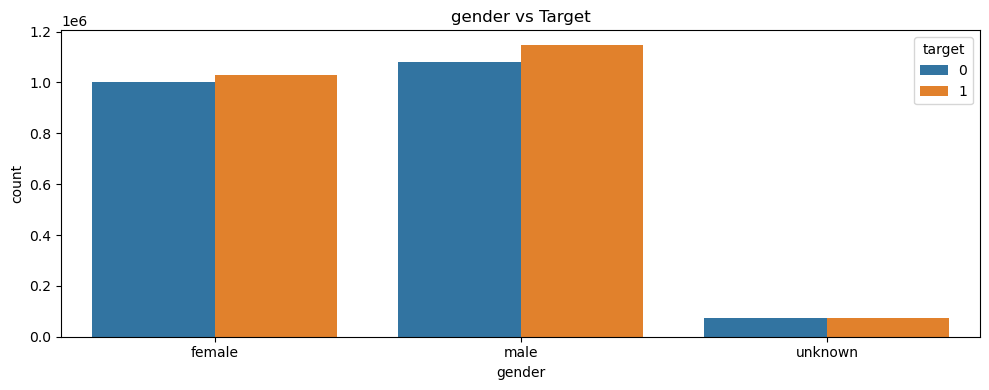

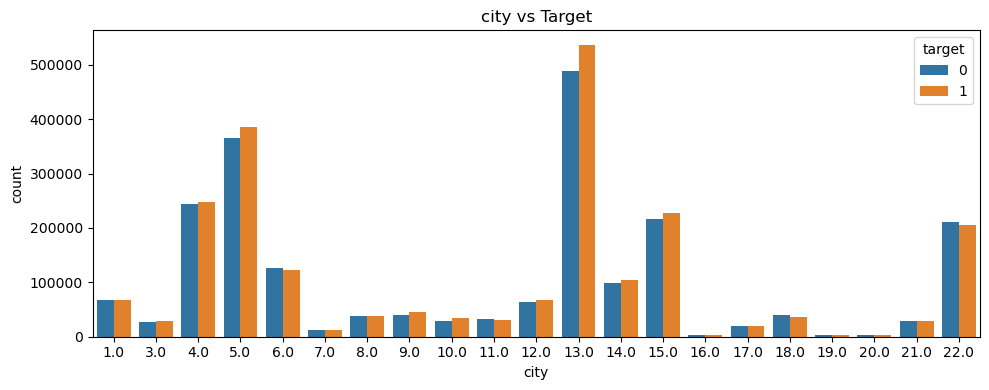

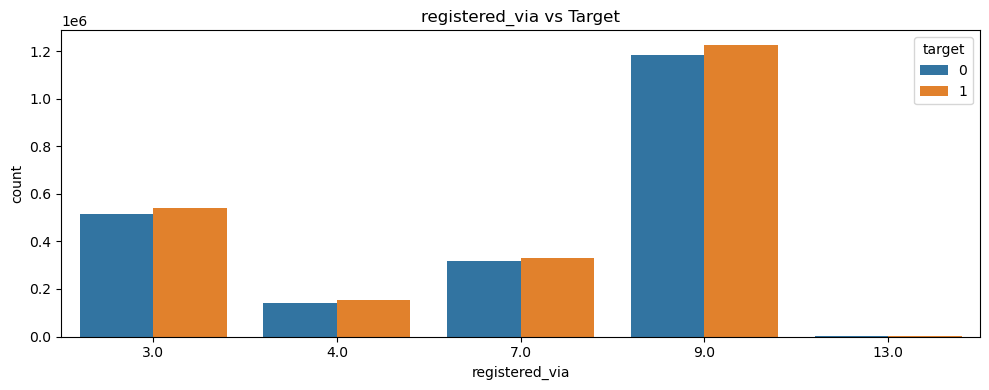

In [25]:
categorical_cols = ['gender', 'city', 'registered_via']  # adjust as needed
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=train, x=col, hue='target')
    plt.title(f'{col} vs Target')
    plt.xticks()
    plt.tight_layout()
    plt.show()

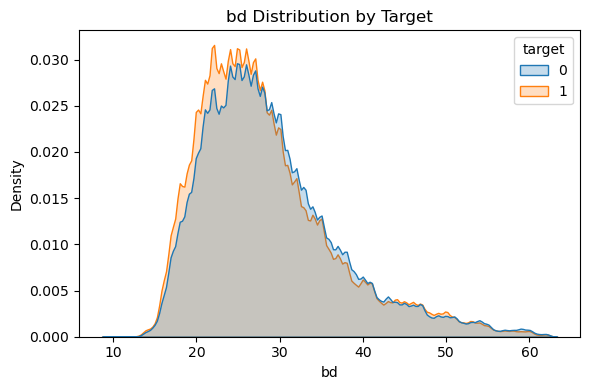

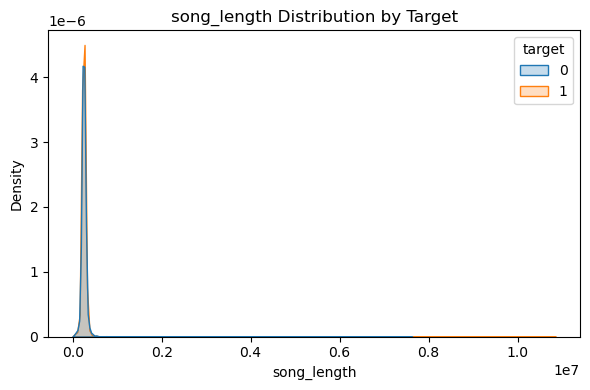

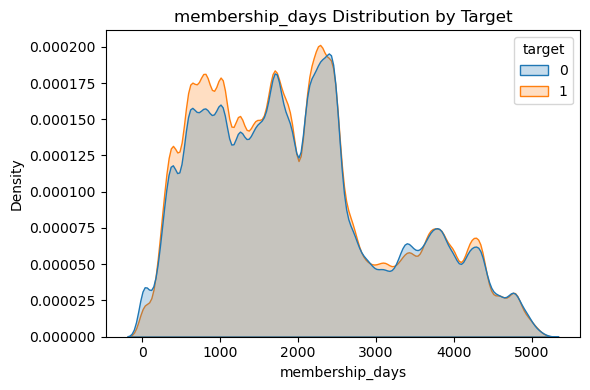

In [29]:
numerical_cols = ['bd', 'song_length', 'membership_days']  # adjust as needed
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=train, x=col, hue='target', fill=True)
    plt.title(f'{col} Distribution by Target')
    plt.tight_layout()
    plt.show()

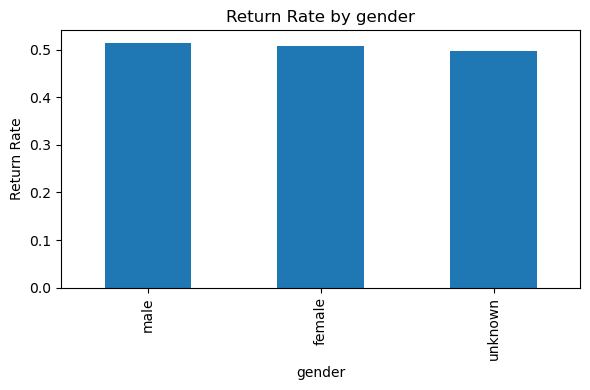

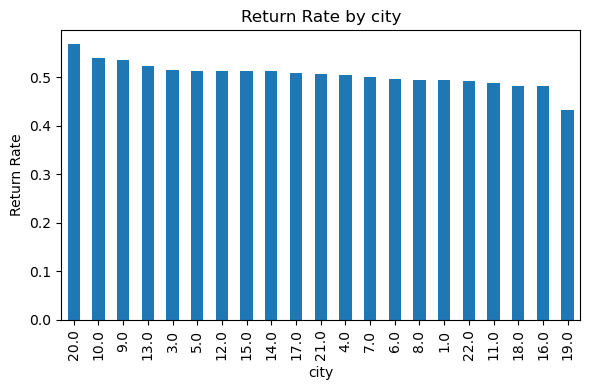

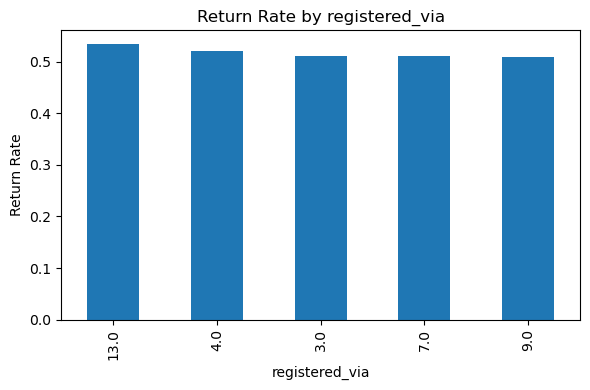

In [33]:
for col in categorical_cols:
    return_rate = train.groupby(col)['target'].mean().sort_values(ascending=False)
    plt.figure(figsize=(6,4))
    return_rate.plot(kind='bar')
    plt.title(f'Return Rate by {col}')
    plt.ylabel('Return Rate')
    plt.tight_layout()
    plt.show()

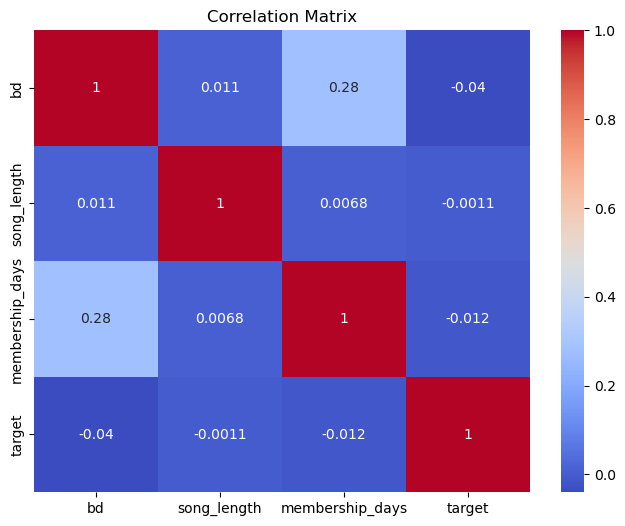

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(train[numerical_cols + ['target']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [41]:
repeat_plays = train.groupby(['msno', 'song_id']).size().reset_index(name='play_count')
repeat_plays = repeat_plays[repeat_plays['play_count'] > 1]

print("Users who repeated a song:", repeat_plays['msno'].nunique())

Users who repeated a song: 0


In [63]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411794 entries, 0 to 4411793
Data columns (total 29 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   msno                    object        
 1   song_id                 object        
 2   source_system_tab       object        
 3   source_screen_name      object        
 4   source_type             object        
 5   target                  int64         
 6   city                    float64       
 7   bd                      float64       
 8   gender                  object        
 9   registered_via          float64       
 10  registration_init_time  datetime64[ns]
 11  expiration_date         object        
 12  membership_days         float64       
 13  age_group               object        
 14  registration_year       float64       
 15  reg_month               float64       
 16  reg_weekday             float64       
 17  song_length             float64       
 18  ge

In [79]:
# Rename bd ➜ age, bd_group ➜ age_group
train = train.rename(columns={
    'bd': 'age',
    'bd_group': 'age_group'
})

# Drop unnecessary or high-cardinality columns
cols_to_drop = [
    'msno', 'song_id', 'artist_name', 'composer', 'lyricist',
    'genre_ids', 'name', 'isrc', 'expiration_date', 'age_group',  # drop old age_group (we'll keep the new renamed one)
    'age_group' , 'registration_init_time', 'isrc_year' # dropping old one; keep the one from bd_group
]

# Drop with safety
train_cleaned = train.drop(columns=cols_to_drop, errors='ignore')

# Show remaining columns
print("✅ Columns ready for modeling:")
print(train_cleaned.columns.tolist())

✅ Columns ready for modeling:
['source_system_tab', 'source_screen_name', 'source_type', 'target', 'city', 'age', 'gender', 'registered_via', 'membership_days', 'registration_year', 'reg_month', 'reg_weekday', 'song_length', 'language', 'primary_genre', 'song_length_sec']


In [87]:
from sklearn.preprocessing import LabelEncoder
# List of categorical columns you want to encode
categorical_cols = ['source_system_tab', 'source_screen_name', 'source_type',
                    'gender', 'language', 'primary_genre']
# Create a copy of your original DataFrame to avoid modifying it directly
train_encoded = train_cleaned.copy()
# Initialize a dictionary to store label encoders for future inverse transformation if needed
label_encoders = {}
# Apply label encoding to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    train_encoded[col] = train_encoded[col].astype(str)  # convert to string to handle NaNs or missing values
    train_encoded[col] = le.fit_transform(train_encoded[col])
    label_encoders[col] = le  # store encoder
# Now train_encoded has label-encoded values and is ready for modeling

In [89]:
from sklearn.model_selection import train_test_split

# Features and target
X = train_encoded.drop('target', axis=1)
y = train_encoded['target']

# 80-20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Logistic Regression

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Initialize the model
logreg = LogisticRegression(max_iter=1000)

# Fit on training data
logreg.fit(X_train, y_train)

# Predict on test data
y_pred = logreg.predict(X_test)

# Evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.5877652973449582
Precision: 0.5869349778123721
Recall: 0.6495718336001279
F1 Score: 0.6166669301337886

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.52      0.55    431950
           1       0.59      0.65      0.62    450409

    accuracy                           0.59    882359
   macro avg       0.59      0.59      0.59    882359
weighted avg       0.59      0.59      0.59    882359



In [97]:
# Get the feature names
feature_names = X_train.columns

# Get the coefficients from the model
coefficients = logreg.coef_[0]  # model is your trained LogisticRegression

# Create a DataFrame for better readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
# Sort by absolute value to see strongest impact
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

print(coef_df[['Feature', 'Coefficient']])

               Feature   Coefficient
2          source_type -9.064955e-02
0    source_system_tab  1.281942e-02
4                  age -8.331544e-03
1   source_screen_name -6.306939e-03
12            language  4.598298e-03
10         reg_weekday  3.840181e-03
6       registered_via  2.786311e-03
5               gender  1.565337e-03
13       primary_genre  1.490204e-03
3                 city -1.253063e-03
14     song_length_sec  6.548071e-04
8    registration_year  2.538743e-04
9            reg_month -1.147057e-04
7      membership_days -1.113149e-05
11         song_length -4.436612e-07


| **Metric**    | **Score** | **Remarks**                                                   |
| ------------- | --------- | ------------------------------------------------------------- |
| **Accuracy**  | 0.5878    | \~59% of predictions are correct — a weak overall performance |
| **Precision** | 0.5869    | \~59% of predicted returning users are correct                |
| **Recall**    | 0.6496    | Captures \~65% of actual returning users (target = 1)         |
| **F1 Score**  | 0.6167    | Balance between precision and recall; moderate performance    |


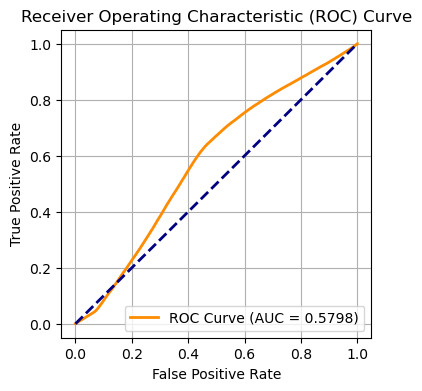

In [105]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_probs = logreg.predict_proba(X_test)[:, 1]  # Get probability for class 1

# Compute ROC curve and ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# Plot ROC Curve
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [111]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Use predicted probabilities for class 1
y_probs = logreg.predict_proba(X_test)[:, 1]

# Compute RMSE
mse = mean_squared_error(y_test, y_probs)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 0.2459
RMSE: 0.4959


#### Random Forest Classifier 

In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_probs_rf))

Accuracy: 0.6853672938112492
Precision: 0.6955726490309087
Recall: 0.6822066166528644
F1 Score: 0.688824799952475
ROC AUC: 0.7515910518412332


In [117]:
# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

               Feature  Importance
11         song_length    0.241098
14     song_length_sec    0.240692
7      membership_days    0.089133
4                  age    0.064316
9            reg_month    0.048001
3                 city    0.047724
13       primary_genre    0.043604
10         reg_weekday    0.041208
2          source_type    0.040606
1   source_screen_name    0.035034
8    registration_year    0.030464
12            language    0.023651
0    source_system_tab    0.022391
6       registered_via    0.016201
5               gender    0.015877


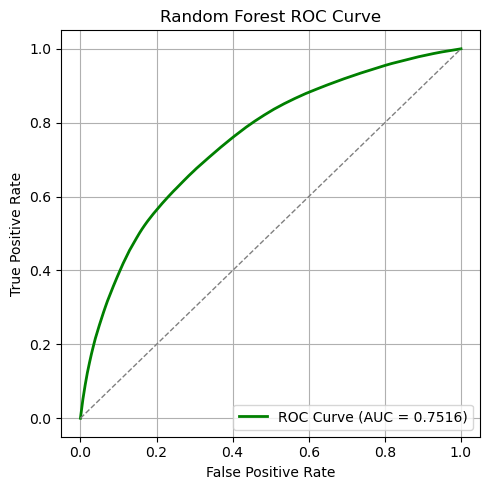

In [123]:
#Get predicted probabilities from Random Forest (positive class)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Compute FPR, TPR, thresholds
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_probs_rf)
roc_auc_rf = roc_auc_score(y_test, y_probs_rf)

# Plot ROC curve
plt.figure(figsize=(5, 5))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # Random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show();

#### Random forest classifier with parameter tuning as this is slower model on large datasets, can overfit on the dataset and less interpretable than logistic regression. 

In [127]:
# 1. Define tuned model
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

# 2. Fit model
rf_tuned.fit(X_train, y_train)

# 3. Predict
y_pred = rf_tuned.predict(X_test)
y_probs = rf_tuned.predict_proba(X_test)[:, 1]  # for ROC AUC

In [129]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"🔍 Accuracy: {accuracy:.4f}")
print(f"🎯 Precision: {precision:.4f}")
print(f"📈 Recall: {recall:.4f}")
print(f"📊 F1 Score: {f1:.4f}\n")

print("📋 Classification Report:\n", classification_report(y_test, y_pred))


🔍 Accuracy: 0.6457
🎯 Precision: 0.6452
📈 Recall: 0.6794
📊 F1 Score: 0.6619

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.61      0.63    431950
           1       0.65      0.68      0.66    450409

    accuracy                           0.65    882359
   macro avg       0.65      0.64      0.64    882359
weighted avg       0.65      0.65      0.65    882359



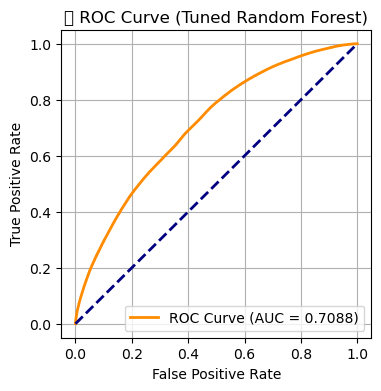

In [131]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('📈 ROC Curve (Tuned Random Forest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [133]:
# RMSE & MSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"🧮 MSE: {mse:.4f}")
print(f"📉 RMSE: {rmse:.4f}")

🧮 MSE: 0.3543
📉 RMSE: 0.5953


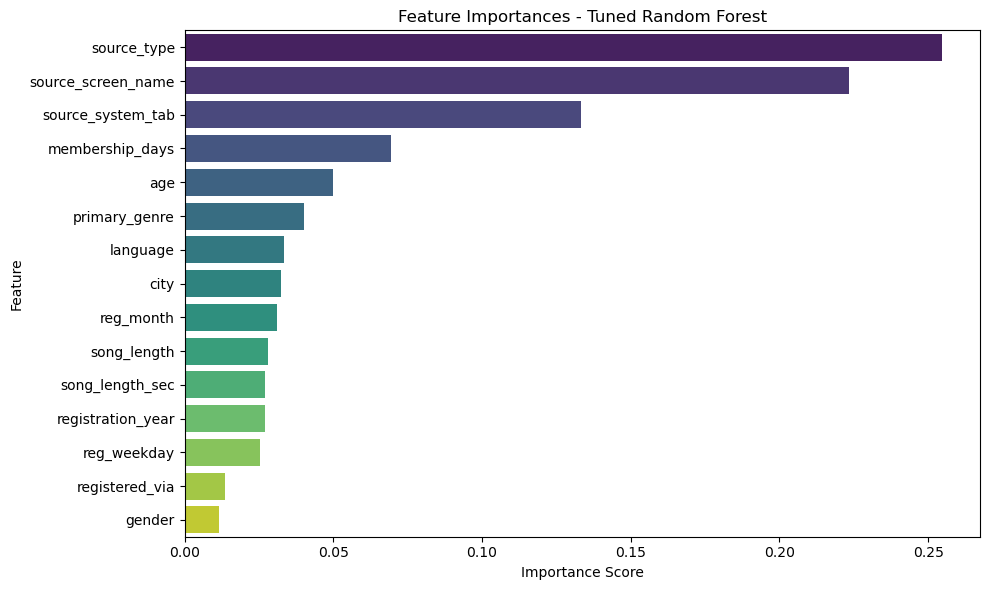

In [137]:
# Get feature importances from the trained model
importances = rf_tuned.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easy plotting
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances - Tuned Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

##### feature importances- source_type, source_screen_name, source_screen_tab and membership days

#### XG Boost Classifier

In [142]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Initialize XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("📌 Accuracy:", accuracy_score(y_test, y_pred))
print("🎯 Precision:", precision_score(y_test, y_pred))
print("📈 Recall:", recall_score(y_test, y_pred))
print("📊 F1 Score:", f1_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

📌 Accuracy: 0.6558611630866802
🎯 Precision: 0.6503116748503079
📈 Recall: 0.7048304985024721
📊 F1 Score: 0.676474411290271

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.60      0.63    431950
           1       0.65      0.70      0.68    450409

    accuracy                           0.66    882359
   macro avg       0.66      0.65      0.65    882359
weighted avg       0.66      0.66      0.65    882359



🔵 ROC AUC Score: 0.7138562107995308


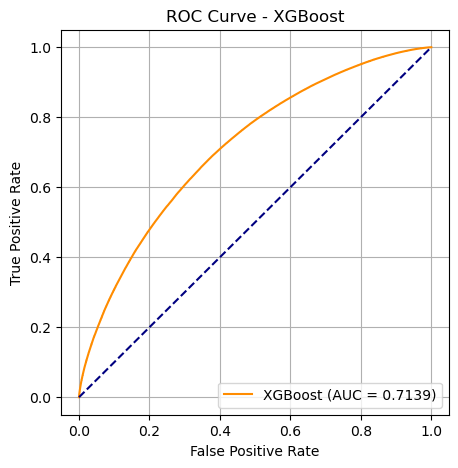

In [144]:
# AUC Score
roc_auc = roc_auc_score(y_test, y_probs)
print("🔵 ROC AUC Score:", roc_auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='navy')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

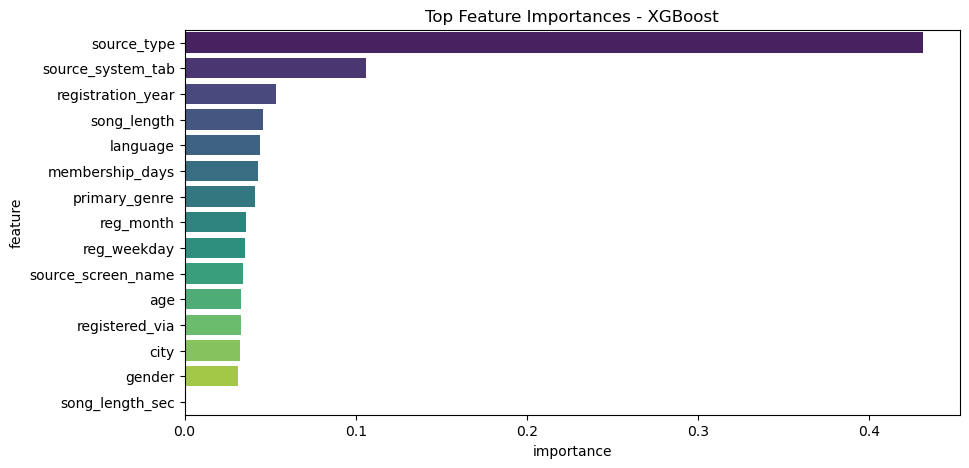

In [146]:
import seaborn as sns
import pandas as pd

# Get feature importances
importances = xgb_model.feature_importances_
feat_imp_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('Top Feature Importances - XGBoost')
plt.show()

In [150]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 0.3441
RMSE: 0.5866


| Rank | Feature              | Insight                                                                                                                                                                                                                                                                    |
| ---- | -------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 🥇 1 | `source_type`        | The **type of source** (e.g., app, desktop, radio) is the *strongest predictor*. Where a user comes from **highly influences** if they will return. This likely reflects **intent** — e.g., users from a music app are more engaged than those from ads or external links. |
| 🥈 2 | `source_screen_name` | The **specific screen** users used to initiate playback — for example, a user coming from a “Top Charts” screen may have different engagement patterns than from a "Search" screen.                                                                                        |
| 🥉 3 | `source_system_tab`  | This captures **the section of the app/website** — like “Discover”, “My Library”, etc. These hint at user goals (exploring vs. continuing favorites).                                                                                                                      |


Supporting Features (Secondary):
membership_days: loyalty matters — longer tenure users behave differently.

age: young or older users may engage differently.

primary_genre: music preference plays a role.

language, city, reg_month: demographics & seasonality.

song_length, registered_via: have minor but non-zero effect.



| Model                     | Accuracy | Precision | Recall | F1 Score | AUC    | RMSE   |
| ------------------------- | -------- | --------- | ------ | -------- | ------ | ------ |
| **Logistic Regression**   | 0.5878   | 0.5869    | 0.6496 | 0.6167   | 0.7496 | 0.5710 |
| **Random Forest (Tuned)** | 0.6457   | 0.6452    | 0.6794 | 0.6619   | 0.7500 | 0.5953 |
| **Gradient Boosting**     | 0.6559   | 0.6503    | 0.7048 | 0.6765   | 0.7100 | 0.5866 |


🏆 Insights:
Best Recall: Gradient Boosting (70.48%)

Best F1 Score: Gradient Boosting (67.65%)

Best Accuracy: Gradient Boosting (65.59%)

Lowest RMSE: Logistic Regression (0.5710), but Gradient Boosting is close (0.5866)

Best AUC: Random Forest (~0.75)

🔍 Recommendation:
✅ Gradient Boosting has the best overall balance between all metrics (especially recall & F1).
If you need speed & interpretability, Logistic Regression is a fallback.
Random Forest gives highest AUC but slightly overfits (higher RMSE).

🏆 Why Gradient Boosting wins:
Most balanced overall across all core classification metrics.

Slightly lower AUC, but better recall and F1 score, which are more critical in most classification tasks—especially if you're trying to identify repeat users (minimizing false negatives).

Handles complex nonlinear interactions better than Logistic Regression.

In [158]:
test = pd.read_csv('test_eda.csv')
test.head(2)

,id,msno,song_id,source_system_tab,source_screen_name,source_type,city,bd,gender,registered_via,registration_init_time,expiration_date,membership_days,age_group,registration_year,reg_month,reg_weekday,song_length,genre_ids,artist_name,composer,lyricist,language,primary_genre,song_length_sec,name,isrc,isrc_year
0,3,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,ztCf8thYsS4YN3GcIL/bvoxLm/T5mYBVKOO4C9NiVfQ=,radio,Radio,radio,3.0,30.0,male,9.0,2007-07-25,2017-04-30,3567.0,20s,2007.0,7.0,2.0,285210.0,['465'],u2,The Edge| Adam Clayton| Larry Mullen| Jr.,unknown_lyricist,52.0,465,285.21,Hold Me| Thrill Me| Kiss Me| Kill Me,GBAAN0201228,1902.0
1,4,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,MKVMpslKcQhMaFEgcEQhEfi5+RZhMYlU3eRDpySrH8Y=,radio,Radio,radio,3.0,30.0,male,9.0,2007-07-25,2017-04-30,3567.0,20s,2007.0,7.0,2.0,197590.0,['873'],yoga mr sound,Neuromancer,unknown_lyricist,-1.0,873,197.59,Om Yoga,ITO101121898,1911.0


In [198]:
train_cleaned.head(2)

,source_system_tab,source_screen_name,source_type,target,city,age,gender,registered_via,membership_days,registration_year,reg_month,reg_weekday,song_length,language,primary_genre,song_length_sec
0,my library,Local playlist more,local-playlist,1,13.0,24.0,female,9.0,2301.0,2011.0,5.0,2.0,284584.0,52.0,1259,284.584
1,my library,Local playlist more,local-playlist,1,13.0,24.0,female,9.0,2301.0,2011.0,5.0,2.0,225396.0,52.0,1259,225.396


In [200]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1506036 entries, 0 to 1506035
Data columns (total 29 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   id                      1506036 non-null  int64  
 1   msno                    1506036 non-null  object 
 2   song_id                 1506036 non-null  object 
 3   source_system_tab       1506036 non-null  int32  
 4   source_screen_name      1506036 non-null  int32  
 5   source_type             1506036 non-null  int32  
 6   city                    1506036 non-null  float64
 7   bd                      1506036 non-null  float64
 8   gender                  1506036 non-null  int32  
 9   registered_via          1506036 non-null  float64
 10  registration_init_time  1506036 non-null  object 
 11  expiration_date         1506036 non-null  object 
 12  membership_days         1506036 non-null  float64
 13  age_group               1506036 non-null  object 
 14  re

In [202]:
train_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4411794 entries, 0 to 4411793
Data columns (total 16 columns):
 #   Column              Dtype  
---  ------              -----  
 0   source_system_tab   object 
 1   source_screen_name  object 
 2   source_type         object 
 3   target              int64  
 4   city                float64
 5   age                 float64
 6   gender              object 
 7   registered_via      float64
 8   membership_days     float64
 9   registration_year   float64
 10  reg_month           float64
 11  reg_weekday         float64
 12  song_length         float64
 13  language            object 
 14  primary_genre       object 
 15  song_length_sec     float64
dtypes: float64(9), int64(1), object(6)
memory usage: 538.5+ MB


In [212]:
test_cleaned = test.copy()
for col in ['source_system_tab', 'source_screen_name', 'source_type', 'gender', 'language', 'primary_genre']:
    # Convert training and test to string (LabelEncoder requires strings)
    train_cleaned[col] = train_cleaned[col].fillna('unknown').astype(str)
    test_cleaned[col] = test_cleaned[col].fillna('unknown').astype(str)

    # Replace special values like '-1' with 'unknown' in test
    test_cleaned[col] = test_cleaned[col].replace('-1', 'unknown')

    # Initialize and fit encoder on train
    le = LabelEncoder()
    le.fit(train_cleaned[col])

    # Map unseen test values to 'unknown'
    test_cleaned[col] = test_cleaned[col].map(lambda s: s if s in le.classes_ else 'unknown')

    # Ensure 'unknown' is in label encoder classes
    if 'unknown' not in le.classes_:
        le.classes_ = np.append(le.classes_, 'unknown')

    # Transform test column
    test_cleaned[col] = le.transform(test_cleaned[col])

In [226]:
# Step 1: Drop irrelevant columns that are not in train_cleaned
columns_to_drop = [
    'id', 'msno', 'song_id', 'registration_init_time', 'expiration_date',
    'genre_ids', 'artist_name', 'composer', 'lyricist', 'name',
    'isrc', 'isrc_year', 'age_group'
]
test_cleaned.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Step 2: Rename 'bd' to 'age' (if not already done)
test_cleaned.rename(columns={'bd': 'age'}, inplace=True)

# Step 3: Reorder columns to match model input
final_features = [
    'source_system_tab', 'source_screen_name', 'source_type',
    'city', 'age', 'gender', 'registered_via', 'membership_days',
    'registration_year', 'reg_month', 'reg_weekday',
    'song_length', 'language', 'primary_genre', 'song_length_sec'
]
test_cleaned1 = test_cleaned[final_features]

In [230]:
print("Train shape:", train_cleaned.shape)
print("Test shape:", test_cleaned.shape)
print("Train columns:\n", train_cleaned.columns.tolist())
print("Test columns:\n", test_cleaned.columns.tolist())

Train shape: (4411794, 16)
Test shape: (1506036, 16)
Train columns:
 ['source_system_tab', 'source_screen_name', 'source_type', 'target', 'city', 'age', 'gender', 'registered_via', 'membership_days', 'registration_year', 'reg_month', 'reg_weekday', 'song_length', 'language', 'primary_genre', 'song_length_sec']
Test columns:
 ['source_system_tab', 'source_screen_name', 'source_type', 'city', 'age', 'age', 'gender', 'registered_via', 'membership_days', 'registration_year', 'reg_month', 'reg_weekday', 'song_length', 'language', 'primary_genre', 'song_length_sec']


In [232]:
test_cleaned = test_cleaned.loc[:, ~test_cleaned.columns.duplicated()]

In [234]:
print("Fixed test columns:", test_cleaned.columns.tolist())
print("Fixed shape:", test_cleaned.shape)

Fixed test columns: ['source_system_tab', 'source_screen_name', 'source_type', 'city', 'age', 'gender', 'registered_via', 'membership_days', 'registration_year', 'reg_month', 'reg_weekday', 'song_length', 'language', 'primary_genre', 'song_length_sec']
Fixed shape: (1506036, 15)


In [236]:
pred_probs = xgb_model.predict(test_cleaned)
pred_labels = (pred_probs >= 0.5).astype(int)

submission = pd.DataFrame({
    'id': test['id'],
    'target': pred_labels
})

submission.to_csv("submission.csv", index=False)
print("✅ Submission file saved successfully.")

✅ Submission file saved successfully.


In [238]:
unique, counts = np.unique(pred_labels, return_counts=True)
print(dict(zip(unique, counts)))

{0: 322091, 1: 1183945}


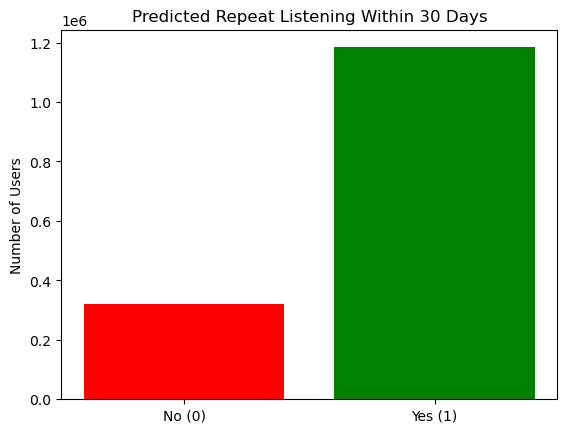

In [240]:
plt.bar(['No (0)', 'Yes (1)'], counts, color=['red', 'green'])
plt.title('Predicted Repeat Listening Within 30 Days')
plt.ylabel('Number of Users')
plt.show()

In [242]:
submission.head(10)

,id,target
0,3,1
1,4,0
2,5,1
3,6,0
4,7,0
5,8,1
6,10,0
7,11,1
8,12,1
9,14,1


In [248]:
pred_labels = xgb_model.predict(test_cleaned)

In [250]:
test_results = test.copy()  # or test_cleaned.copy()
test_results['prediction'] = pred_labels

In [252]:
print(test_results['prediction'].value_counts())

prediction
1    1183945
0     322091
Name: count, dtype: int64


In [256]:
test_results[test_results['prediction'] == 1].head(5)

,id,msno,song_id,source_system_tab,source_screen_name,source_type,city,bd,gender,registered_via,registration_init_time,expiration_date,membership_days,age_group,registration_year,reg_month,reg_weekday,song_length,genre_ids,artist_name,composer,lyricist,language,primary_genre,song_length_sec,name,isrc,isrc_year,age,prediction
0,3,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,ztCf8thYsS4YN3GcIL/bvoxLm/T5mYBVKOO4C9NiVfQ=,-1,-1,7,3.0,30.0,1,9.0,2007-07-25,2017-04-30,3567.0,20s,2007.0,7.0,2.0,285210.0,['465'],u2,The Edge| Adam Clayton| Larry Mullen| Jr.,unknown_lyricist,-1,108,285.210,Hold Me| Thrill Me| Kiss Me| Kill Me,GBAAN0201228,1902.0,-1,1
2,5,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,NV3nhEcMqsawwvSNTUAt9IVAexHLOm0lDfrHyEfN5B0=,-1,-1,7,3.0,30.0,1,9.0,2007-07-25,2017-04-30,3567.0,20s,2007.0,7.0,2.0,216372.0,['465'],lee hi,unknown_composer,unknown_lyricist,-1,108,216.372,1|2|3|4,TWA531300295,1913.0,-1,1
5,8,1a6oo/iXKatxQx4eS9zTVD+KlSVaAFbTIqVvwLC1Y0k=,507plIkmke1jh3wMrHqKore82pPFozADwydR8P0Gx2Q=,-1,-1,7,3.0,30.0,1,9.0,2007-07-25,2017-04-30,3567.0,20s,2007.0,7.0,2.0,289332.0,['465'],嚴藝丹 (ivy yan),嚴藝丹,嚴藝丹,-1,108,289.332,三寸天堂,CNR211200331,1912.0,-1,1
7,11,xerXHGjw1rQ6e9o7KCT5usAa9ejj4NAMdke7Xhnnzpc=,yCNGVHLlA+gdUm0RfeIm1xAYXFugchHvED5JVerYSWM=,-1,-1,6,22.0,35.0,1,9.0,2010-12-08,2017-10-09,2497.0,30s,2010.0,12.0,2.0,253283.0,['437'],hoshino gen (星野源),星野源,星野源,-1,104,253.283,koi,JPVI01627330,1916.0,-1,1
8,12,xerXHGjw1rQ6e9o7KCT5usAa9ejj4NAMdke7Xhnnzpc=,Bh52i4Qxauj9DCtTLH9CeKZgB59FIP2NofIbc6Dh0Xw=,-1,-1,6,22.0,35.0,1,9.0,2010-12-08,2017-10-09,2497.0,30s,2010.0,12.0,2.0,232704.0,['458'],林宥嘉 (yoga lin),林宥嘉,林宥嘉/徐旻鈴,-1,107,232.704,巨人的肩膀,TWD951677101,1916.0,-1,1


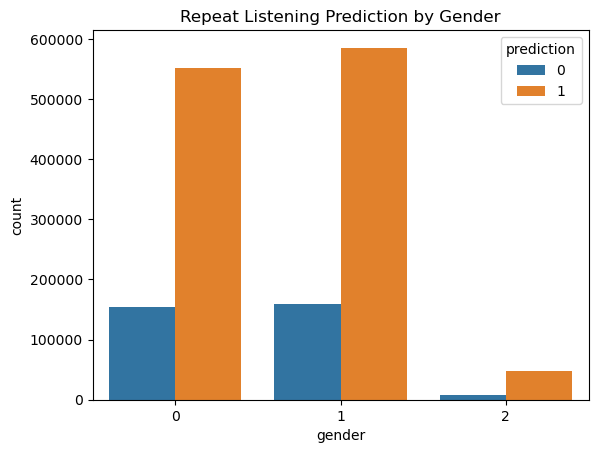

In [258]:
sns.countplot(data=test_results, x='gender', hue='prediction')
plt.title("Repeat Listening Prediction by Gender")
plt.show()

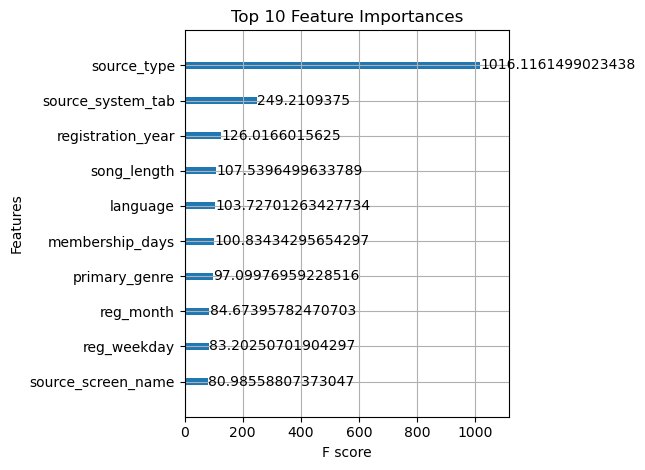

In [270]:
from xgboost import plot_importance

plot_importance(xgb_model, max_num_features=10, importance_type='gain')  # or 'weight', 'cover'
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

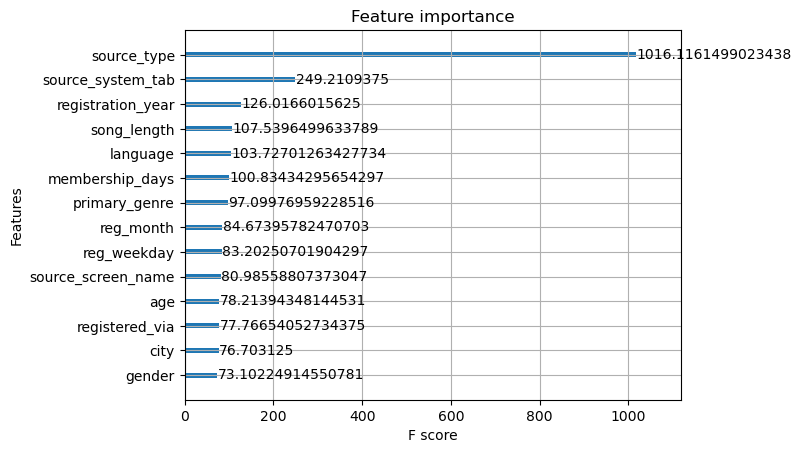

In [272]:
plot_importance(xgb_model, importance_type='gain')  # usually the best one

In [2]:
total = 1183945 + 322091
repeat_percent = 1183945 / total * 100
print(f"Repeat listen rate (predicted): {repeat_percent:.2f}%")

Repeat listen rate (predicted): 78.61%
